# Biomedical Image Analysis Pipeline 

**Assignment 3**




**Tamanna Pathak**


### One-time setup
```bash
!curl -fsSL https://ollama.com/install.sh | sh   # or download from https://ollama.com/download
!ollama serve                                  
!ollama pull llava:7b                            
!ollama pull qwen2.5:3b                          
```

In [1]:
!ollama pull llava:7b                            
!ollama pull qwen2.5:3b  

]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling 170370233dd5: 100% ▕██████████████████▏ 4.1 GB                         
pulling 72d6f08a42f6: 100% ▕██████████████████▏ 624 MB                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling c43332387573: 100% ▕██████████████████▏   67 B                         
pulling ed11eda7790d: 100% ▕██████████████████▏   30 B                         
pulling 7c658f9561e5: 100% ▕██████████████████▏  564 B                         
verifying sha256 digest 
writing manifest 
success 
]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling 5ee4f07cdb9b: 100% ▕██████████████████▏ 1.9 GB                         
pulling 66b9ea09bd5b: 100% ▕████

In [2]:
from __future__ import annotations

import os, sys, re, json, random, warnings
from dataclasses import dataclass
from typing import Callable, List, Optional

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, opening, closing, disk
from skimage.measure import label, regionprops_table
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter

try:
    from ollama import chat
    _OLLAMA_IMPORT_OK = True
except ImportError:
    _OLLAMA_IMPORT_OK = False

print("Third-party libraries imported OK.")

Third-party libraries imported OK.


## Core Functions

### 1. Configuration

In [3]:
@dataclass
class PipelineConfig:
    '''Not frozen deliberately -- e.g. in a later cell you can do
    `CONFIG.epochs = 3` for a quick smoke-test run without editing this cell.'''


    seed: int = 0


    image_size: tuple = (256, 256)

    # -- U-Net training --
    epochs: int = 15
    batch_size: int = 8
    learning_rate: float = 1e-3
    base_channels: int = 16
    loss_bce_weight: float = 0.5  # weighting inside BCEDiceLoss

    # -- Ollama models
    vlm_model: str = "llava:7b"
    text_llm_model: str = "qwen2.5:3b"   
    llm_temperature: float = 0.0         # 0.0 = deterministic
    llm_max_retries: int = 4            
                                        


CONFIG = PipelineConfig()


def set_global_seed(seed: int = CONFIG.seed) -> None:
    '''
    Call this immediately before any randomised operation  that needs to be reproducible run to run. I
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print("Configuration defined.")

Configuration defined.


### 2. Data loading & EDA utilities

Loading and pre-processing utilities for the nuclei microscopy dataset, plus simple exploratory
data analysis 

In [4]:
TARGET_SIZE = CONFIG.image_size 


@dataclass
class ImageRecord:
    '''One image/mask/label triple, identified by image_id.'''
    image_id: str
    split: str
    image_path: str
    mask_path: str
    label_path: str


def list_split(data_root: str, split: str) -> List[ImageRecord]:
    '''Build a list of ImageRecord objects for a given split ('train', 'val', 'test').
    '''
    img_dir = os.path.join(data_root, split, "images")
    mask_dir = os.path.join(data_root, split, "masks")
    label_dir = os.path.join(data_root, split, "labels")

    records = []
    for fname in sorted(os.listdir(img_dir)):
        if not fname.lower().endswith(".png"):
            continue
        image_id = os.path.splitext(fname)[0]
        records.append(ImageRecord(
            image_id=image_id,
            split=split,
            image_path=os.path.join(img_dir, fname),
            mask_path=os.path.join(mask_dir, fname),
            label_path=os.path.join(label_dir, fname),
        ))
    return records


def load_grayscale(path: str, size=TARGET_SIZE) -> np.ndarray:
    '''Load an image, convert to grayscale, resize to `size`, return uint8 array.'''
    img = Image.open(path).convert("L")  
    if img.size != size:
        img = img.resize(size, Image.BILINEAR)
    return np.array(img, dtype=np.uint8)


def load_rgb(path: str, size=TARGET_SIZE) -> np.ndarray:
    '''Load an image as RGB, resize to `size`.'''
    img = Image.open(path).convert("RGB")
    if img.size != size:
        img = img.resize(size, Image.BILINEAR)
    return np.array(img, dtype=np.uint8)


def load_binary_mask(path: str, size=TARGET_SIZE) -> np.ndarray:
    '''Load a ground-truth mask and binarise it to {0, 1}.'''
    img = Image.open(path).convert("L")
    if img.size != size:
        img = img.resize(size, Image.NEAREST)  # nearest-neighbour: preserve labels
    arr = np.array(img)
    return (arr > 127).astype(np.uint8)


def plot_sample_grid(records: List[ImageRecord], n: int = 6, seed: int = 0, save_path: str | None = None):
    '''Plot a grid of `n` sample pairs for the EDA section.
    '''
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(records), size=min(n, len(records)), replace=False)

    fig, axes = plt.subplots(2, len(chosen), figsize=(2.6 * len(chosen), 5.4))
    for col, idx in enumerate(chosen):
        rec = records[idx]
        gray = load_grayscale(rec.image_path)
        mask = load_binary_mask(rec.mask_path)

        axes[0, col].imshow(gray, cmap="gray")
        axes[0, col].set_title(rec.image_id, fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(mask, cmap="gray")
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("image", fontsize=10)
    axes[1, 0].set_ylabel("mask", fontsize=10)
    fig.suptitle("EDA: sample grayscale images (top) and ground-truth masks (bottom)")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def plot_intensity_histogram(records: List[ImageRecord], save_path: str | None = None):
    '''Plot the pooled pixel-intensity histogram across a list of images.

    '''
    all_pixels = []
    for rec in records:
        gray = load_grayscale(rec.image_path)
        all_pixels.append(gray.ravel())
    all_pixels = np.concatenate(all_pixels)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(all_pixels, bins=64, color="#3b6ea5", alpha=0.85)
    ax.set_xlabel("Pixel intensity (0-255)")
    ax.set_ylabel("Pixel count")
    ax.set_title(f"Pooled intensity histogram ({len(records)} images)")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig, all_pixels


def dataset_summary_table(data_root: str) -> pd.DataFrame:
    '''Read metadata.csv  and return it as a DataFrame'''
    return pd.read_csv(os.path.join(data_root, "metadata.csv"))


print("Data loading & EDA utilities defined.")

Data loading & EDA utilities defined.


### 3. Classical image processing (Otsu threshold + regionprops)


In [5]:
# Properties we extract per connected component (nucleus candidate).
REGION_PROPERTIES = [
    "label",
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "extent",
    "equivalent_diameter_area",
    "mean_intensity",
    "major_axis_length",
    "minor_axis_length",
    "centroid",
]


def otsu_segment(gray_img: np.ndarray) -> np.ndarray:
    '''Global Otsu threshold. Returns a binary foreground mask (1 = nucleus candidate).

    '''
    thresh = threshold_otsu(gray_img)
    return (gray_img > thresh).astype(bool)


def morphological_cleanup(binary_mask: np.ndarray, min_size: int = 15, closing_radius: int = 1) -> np.ndarray:
    '''Clean up a raw Otsu mask
    '''
    cleaned = closing(binary_mask, disk(closing_radius)) if closing_radius > 0 else binary_mask
    cleaned = ndi.binary_fill_holes(cleaned)
    cleaned = remove_small_objects(cleaned, min_size=min_size)
    cleaned = opening(cleaned, disk(1))  
    return cleaned


def label_and_measure(binary_mask: np.ndarray, intensity_img: np.ndarray) -> pd.DataFrame:
    '''Label connected components and compute a per-object feature table.

    Returns a pandas DataFrame with one row per detected nucleus, columns given by  REGION_PROPERTIES 
    '''
    label_img = label(binary_mask)
    if label_img.max() == 0:
        return pd.DataFrame(columns=REGION_PROPERTIES)
    props = regionprops_table(label_img, intensity_image=intensity_img, properties=REGION_PROPERTIES)
    return pd.DataFrame(props)


def classical_pipeline(gray_img: np.ndarray, min_size: int = 15) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    '''Run the full classical pipeline on one grayscale image.
    '''
    raw_mask = otsu_segment(gray_img)
    clean_mask = morphological_cleanup(raw_mask, min_size=min_size)
    label_img = label(clean_mask)
    feature_df = label_and_measure(clean_mask, gray_img)
    return clean_mask, label_img, feature_df


def summarize_features_as_text(feature_df: pd.DataFrame, image_id: str = "") -> str:
    '''Convert a regionprops feature table into a short natural-language, numbers-only summary
    suitable for a text-only LLM prompt.
    '''
    n = len(feature_df)
    if n == 0:
        return f"Image {image_id}: no objects were detected after segmentation."

    area = feature_df["area"]
    ecc = feature_df["eccentricity"]
    sol = feature_df["solidity"]
    inten = feature_df["mean_intensity"]

    lines = [
        f"Image: {image_id}",
        f"Number of detected objects (nuclei candidates): {n}",
        f"Object area in pixels: mean={area.mean():.1f}, median={area.median():.1f}, "
        f"min={area.min():.0f}, max={area.max():.0f}, std={area.std():.1f}",
        f"Eccentricity (0=circular, 1=elongated): mean={ecc.mean():.2f}, std={ecc.std():.2f}",
        f"Solidity (area / convex-hull area; lower = more irregular / touching objects): "
        f"mean={sol.mean():.2f}, std={sol.std():.2f}",
        f"Mean object intensity (0-255 grayscale): mean={inten.mean():.1f}, std={inten.std():.1f}",
        f"Total foreground area fraction of the image: {area.sum() / (256 * 256):.3f}",
    ]
    return "\n".join(lines)


print("Classical image-processing functions defined.")

Classical image-processing functions defined.


### 4. U-Net model, losses & metrics

In [6]:
# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------

class NucleiDataset(Dataset):
    '''PyTorch Dataset wrapping a list of ImageRecord objects.
    '''

    def __init__(self, records: list[ImageRecord]):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        gray = load_grayscale(rec.image_path).astype(np.float32) / 255.0
        mask = load_binary_mask(rec.mask_path).astype(np.float32)
        image_t = torch.from_numpy(gray).unsqueeze(0)  # (1, H, W)
        mask_t = torch.from_numpy(mask).unsqueeze(0)    # (1, H, W)
        return image_t, mask_t


# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------

class ConvBlock(nn.Module):
    '''Two 3x3 convolutions, each followed by BatchNorm + ReLU.'''

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SmallUNet(nn.Module):
    '''A 3-level U-Net for single-channel input, single-channel (logit) output.
    '''

    def __init__(self, in_channels: int = 1, out_channels: int = 1, base_channels: int = 16):
        super().__init__()
        c = base_channels
        self.enc1 = ConvBlock(in_channels, c)
        self.enc2 = ConvBlock(c, c * 2)
        self.enc3 = ConvBlock(c * 2, c * 4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(c * 4, c * 8)

        self.up3 = nn.ConvTranspose2d(c * 8, c * 4, 2, stride=2)
        self.dec3 = ConvBlock(c * 8, c * 4)
        self.up2 = nn.ConvTranspose2d(c * 4, c * 2, 2, stride=2)
        self.dec2 = ConvBlock(c * 4, c * 2)
        self.up1 = nn.ConvTranspose2d(c * 2, c, 2, stride=2)
        self.dec1 = ConvBlock(c * 2, c)

        self.out_conv = nn.Conv2d(c, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)  # raw logits -- apply sigmoid outside for probabilities


# ---------------------------------------------------------------------------
# Losses and metrics
# ---------------------------------------------------------------------------

def soft_dice_coefficient(pred_prob: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    '''Soft (probability-weighted) Dice coefficient.'''
    pred_flat = pred_prob.reshape(pred_prob.size(0), -1)
    target_flat = target.reshape(target.size(0), -1)
    intersection = (pred_flat * target_flat).sum(dim=1)
    union = pred_flat.sum(dim=1) + target_flat.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()


def dice_score(pred_prob: torch.Tensor, target: torch.Tensor, threshold: float = 0.5, eps: float = 1e-6) -> torch.Tensor:
    '''Standard (hard) Dice coefficient for REPORTING.'''
    pred_bin = (pred_prob > threshold).float()
    pred_flat = pred_bin.reshape(pred_bin.size(0), -1)
    target_flat = target.reshape(target.size(0), -1)
    intersection = (pred_flat * target_flat).sum(dim=1)
    union = pred_flat.sum(dim=1) + target_flat.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()


def iou_score(pred_prob: torch.Tensor, target: torch.Tensor, threshold: float = 0.5, eps: float = 1e-6) -> torch.Tensor:
    '''Intersection-over-Union, computed on the same binarised (threshold=0.5) predictions used
    by dice_score(), so Dice and IoU are directly comparable.'''
    pred_bin = (pred_prob > threshold).float()
    pred_flat = pred_bin.reshape(pred_bin.size(0), -1)
    target_flat = target.reshape(target.size(0), -1)
    intersection = (pred_flat * target_flat).sum(dim=1)
    union = pred_flat.sum(dim=1) + target_flat.sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean()


class DiceLoss(nn.Module):
    '''1 - soft Dice, applied to sigmoid logits'''

    def forward(self, logits, target):
        probs = torch.sigmoid(logits)
        return 1.0 - soft_dice_coefficient(probs, target)


class BCEDiceLoss(nn.Module):
    '''BCE + Dice combined loss , BCE gives a stable, well-behaved
    gradient early in training.'''

    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, target):
        return self.bce_weight * self.bce(logits, target) + (1 - self.bce_weight) * self.dice(logits, target)


# ---------------------------------------------------------------------------
# Train / evaluate loops
# ---------------------------------------------------------------------------

def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3,
                 loss_fn=None, device="cpu", verbose=True):
    '''Train `model` for  epochs.'''
    if loss_fn is None:
        loss_fn = BCEDiceLoss()
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        val_loss, val_dice, val_iou = evaluate_model(model, val_loader, loss_fn=loss_fn, device=device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        if verbose:
            print(f"Epoch {epoch + 1:2d}/{epochs} | train_loss={train_loss:.4f} "
                  f"| val_loss={val_loss:.4f} | val_dice={val_dice:.4f} | val_iou={val_iou:.4f}")

    return history


@torch.no_grad()
def evaluate_model(model, loader, loss_fn=None, device="cpu"):
    '''Run the model over `loader` in eval mode; return (mean_loss, mean_dice, mean_iou).'''
    if loss_fn is None:
        loss_fn = BCEDiceLoss()
    model.eval()
    total_loss, total_dice, total_iou, n_batches = 0.0, 0.0, 0.0, 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = loss_fn(logits, masks)
        probs = torch.sigmoid(logits)
        total_loss += loss.item()
        total_dice += dice_score(probs, masks).item()
        total_iou += iou_score(probs, masks).item()
        n_batches += 1
    return total_loss / n_batches, total_dice / n_batches, total_iou / n_batches


@torch.no_grad()
def per_image_scores(model, dataset, device="cpu") -> "list[dict]":
    '''Compute Dice/IoU for every image individually .'''
    model.eval()
    results = []
    for i in range(len(dataset)):
        image, mask = dataset[i]
        image_b = image.unsqueeze(0).to(device)
        mask_b = mask.unsqueeze(0).to(device)
        logits = model(image_b)
        probs = torch.sigmoid(logits)
        d = dice_score(probs, mask_b).item()
        iou = iou_score(probs, mask_b).item()
        image_id = dataset.records[i].image_id
        results.append({"image_id": image_id, "dice": d, "iou": iou})
    return results


print("U-Net model, losses, and metrics defined.")

U-Net model, losses, and metrics defined.


### 5. Reproducible caching

In [7]:
LOSS_REGISTRY = {
    "bce": lambda: nn.BCEWithLogitsLoss(),
    "dice": lambda: DiceLoss(),
    "bce_dice": lambda: BCEDiceLoss(bce_weight=CONFIG.loss_bce_weight),
}


def train_or_load(tag: str, loss_name: str, train_records, val_records, out_dir: str,
                   epochs: int | None = None, force: bool = False, verbose: bool = True):
    
    epochs = epochs or CONFIG.epochs
    model_dir = os.path.join(out_dir, "models")
    csv_dir = os.path.join(out_dir, "csv")
    model_path = os.path.join(model_dir, f"unet_{tag}.pt")
    hist_path = os.path.join(csv_dir, f"history_{tag}.csv")

    model = SmallUNet(base_channels=CONFIG.base_channels)

    if not force and os.path.exists(model_path) and os.path.exists(hist_path):
        model.load_state_dict(torch.load(model_path, map_location="cpu"))
        model.eval()
        history_df = pd.read_csv(hist_path)
        if verbose:
            print(f"[experiments] '{tag}': loaded cached model + history from outputs/ "
                  f"(pass force=True, or delete {model_path}, to retrain).")
        return model, history_df

    if loss_name not in LOSS_REGISTRY:
        raise ValueError(f"Unknown loss_name '{loss_name}', expected one of {list(LOSS_REGISTRY)}")

    set_global_seed(CONFIG.seed)  
                                  
    train_loader = DataLoader(NucleiDataset(train_records), batch_size=CONFIG.batch_size, shuffle=True)
    val_loader = DataLoader(NucleiDataset(val_records), batch_size=CONFIG.batch_size)
    loss_fn = LOSS_REGISTRY[loss_name]()

    if verbose:
        print(f"[experiments] '{tag}': no cached result found -- training from scratch "
              f"(loss={loss_name}, epochs={epochs}, seed={CONFIG.seed}).")
    history = train_model(model, train_loader, val_loader, epochs=epochs, lr=CONFIG.learning_rate,
                           loss_fn=loss_fn, verbose=verbose)

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(csv_dir, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    history_df = pd.DataFrame(history)
    history_df.insert(0, "epoch", range(len(history_df)))
    history_df.to_csv(hist_path, index=False)

    return model, history_df


print("Train-or-load experiment helper defined.")

Train-or-load experiment helper defined.


### 6. Ollama

In [8]:
# ---------------------------------------------------------------------------
# Exceptions
# ---------------------------------------------------------------------------

class OllamaUnavailableError(RuntimeError):
    '''The local Ollama server (or the specific model requested) could not be reached.'''


class LLMResponseError(RuntimeError):
    '''The model responded, but its output did not parse into valid JSON with all required
    fields/values even after retrying with a corrective prompt.'''


# ---------------------------------------------------------------------------
# Availability + low-level call
# ---------------------------------------------------------------------------

def is_ollama_available() -> bool:
    '''Return True if a local Ollama server responds on the default port.'''
    if not _OLLAMA_IMPORT_OK:
        return False
    try:
        import urllib.request
        urllib.request.urlopen("http://localhost:11434", timeout=1)
        return True
    except Exception:
        return False


def _diagnose_chat_call_error(exc: Exception, model: str) -> str:
    '''Turn a raw exception from ollama.chat() into an actionable fix message.
    '''
    text = str(exc).lower()

    if "unknown model architecture" in text or "mllama" in text:
        return (
            f"Ollama's local engine cannot load '{model}''s architecture."
        )
    if "not found" in text or "try pulling" in text:
        return f"Fix: run `ollama pull {model}`, wait for it to finish, then re-run this cell."
    if "connection" in text and ("refused" in text or "reset" in text):
        return (
            f"The Ollama server appears to have stopped between the availability check and this call "
            f"(e.g. it crashed loading a previous model). Fix: run `ollama serve` (or reopen the desktop "
            f"app) and re-run this cell."
        )
    if "memory" in text or "out of memory" in text:
        return (
            f"'{model}' may be too large for the available RAM/VRAM on this machine. Fix: close other "
            f"applications, or use a smaller model for this step (e.g. `moondream`, ~1.7GB, for "
            f"CONFIG.vlm_model) and re-run this cell."
        )
    return f"Fix: run `ollama pull {model}` if you haven't already, then re-run this cell."


def require_ollama(model: str) -> None:
    '''Raise OllamaUnavailableError with an actionable message if Ollama is not reachable.
    '''
    if not is_ollama_available():
        raise OllamaUnavailableError(
            f"Ollama is not reachable on http://localhost:11434, so '{model}' cannot be called.\n"
            f"Fix: install Ollama , run `ollama pull {model}`, then re-run this cell.\n"
    
        )


# ---------------------------------------------------------------------------
# JSON extraction + validation
# ---------------------------------------------------------------------------

def extract_json_block(text: str) -> tuple[str, dict]:
    '''Split a raw model response into (prose_before_json, parsed_json_dict).
    '''
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end < start:
        raise json.JSONDecodeError("no JSON object found in response", text, 0)
    prose = text[:start].strip()
    json_part = text[start:end + 1]
    return prose, json.loads(json_part)


def parse_model_json(text: str) -> dict:
    '''Convenience wrapper around extract_json_block for callers that only want the dict.'''
    _, record = extract_json_block(text)
    return record


def validate_vlm_record(record: dict) -> list[str]:

    problems = []
    for key in ("modality", "tissue_type", "notable_features", "image_quality"):
        if key not in record:
            problems.append(f"missing field '{key}'")
    if "notable_features" in record and not isinstance(record["notable_features"], list):
        problems.append("'notable_features' must be a list")
    if "image_quality" in record and record["image_quality"] not in {"good", "acceptable", "poor", "uncertain"}:
        problems.append("'image_quality' must be one of good/acceptable/poor/uncertain")
    return problems


def validate_numbers_first_record(record: dict) -> list[str]:
   
    problems = []
    required_types = {
        "n_objects": (int,),
        "density_class": (str,),
        "shape_regularity": (str,),
        "quality_flag": (str,),
    }
    for key, types in required_types.items():
        if key not in record:
            problems.append(f"missing field '{key}'")
        elif not isinstance(record[key], types):
            problems.append(f"'{key}' must be of type {[t.__name__ for t in types]}")
    if "density_class" in record and record["density_class"] not in {"sparse", "normal", "dense", "clustered", "uncertain"}:
        problems.append("'density_class' must be one of sparse/normal/dense/clustered/uncertain")
    if "shape_regularity" in record and record["shape_regularity"] not in {"regular", "mixed", "irregular", "uncertain"}:
        problems.append("'shape_regularity' must be one of regular/mixed/irregular/uncertain")
    if "quality_flag" in record and record["quality_flag"] not in {"good", "review_needed", "uncertain"}:
        problems.append("'quality_flag' must be one of good/review_needed/uncertain")
    return problems


def validate_hybrid_record(record: dict) -> list[str]:
    
    problems = []
    for key in ("image_id", "n_objects", "mean_area", "density_class", "quality_flag"):
        if key not in record:
            problems.append(f"missing field '{key}'")
    if "density_class" in record and record["density_class"] not in {"sparse", "normal", "dense", "clustered", "uncertain"}:
        problems.append("'density_class' must be one of sparse/normal/dense/clustered/uncertain")
    if "quality_flag" in record and record["quality_flag"] not in {"good", "review_needed", "uncertain"}:
        problems.append("'quality_flag' must be one of good/review_needed/uncertain")
    return problems


# ---------------------------------------------------------------------------
# Key-alias normalization 
# ---------------------------------------------------------------------------

_FIELD_ALIASES = {
    "density_class": ["density", "densityclass", "density_category", "density_level"],
    "quality_flag": ["quality", "qualityflag", "quality_class", "quality"],
    "shape_regularity": ["shape", "shaperegularity", "regularity"],
}


def normalize_record_keys(record: dict) -> dict:
 
    normalized = dict(record)
    lower_keys = {str(k).lower().replace(" ", "_"): k for k in record}
    for canonical, aliases in _FIELD_ALIASES.items():
        if canonical in normalized:
            continue
        for alias in aliases:
            if alias in lower_keys:
                normalized[canonical] = normalized.pop(lower_keys[alias])
                break
    return normalized


# ---------------------------------------------------------------------------
# Plain-text call
# ---------------------------------------------------------------------------

def chat_text(model: str, content: str, images: Optional[list] = None,
              temperature: float = CONFIG.llm_temperature) -> str:
    '''Call Ollama and return the raw response text   '''
    require_ollama(model)
    message = {"role": "user", "content": content}
    if images:
        message["images"] = images
    try:
        response = chat(model=model, messages=[message], options={"temperature": temperature})
    except Exception as e:
        raise OllamaUnavailableError(
            f"Ollama is reachable but the call to model '{model}' failed: {e}\n"
            f"{_diagnose_chat_call_error(e, model)}"
        ) from e
    return response["message"]["content"]


# ---------------------------------------------------------------------------
# High-level call: chat -> extract JSON -> validate -> retry-or-raise
# ---------------------------------------------------------------------------

def chat_json(model: str, content: str, images: Optional[list] = None,
              temperature: float = CONFIG.llm_temperature,
              validator: Optional[Callable[[dict], list[str]]] = None,
              max_retries: int = CONFIG.llm_max_retries) -> tuple[str, dict]:
    '''Call Ollama, extract + validate a JSON record, and return (prose, record).
    '''
    require_ollama(model)

    prompt = content
    last_problems: list[str] = []
    last_raw = ""  

    for attempt in range(max_retries + 1):
        message = {"role": "user", "content": prompt}
        if images:
            message["images"] = images

        attempt_temperature = min(temperature + 0.2 * attempt, 0.6) if attempt > 0 else temperature

        try:
            response = chat(model=model, messages=[message], options={"temperature": attempt_temperature})
        except Exception as e:  # e.g. model not pulled, outdated server, connection dropped mid-call
            raise OllamaUnavailableError(
                f"Ollama is reachable but the call to model '{model}' failed: {e}\n"
                f"{_diagnose_chat_call_error(e, model)}"
            ) from e

        raw = response["message"]["content"]
        last_raw = raw

        try:
            prose, record = extract_json_block(raw)
        except json.JSONDecodeError as e:
            last_problems = [f"response did not contain a parseable JSON object ({e})"]
            prompt = (content + f"\n\nYour previous reply could not be parsed as JSON: {e}. "
                                 f"Reply again, including a single valid JSON object.")
            continue

        record = normalize_record_keys(record)
        problems = validator(record) if validator else []
        if not problems:
            return prose, record

        last_problems = problems

        prompt = (content + "\n\nYour previous JSON reply had the following problem(s): "
                             + "; ".join(problems) + ". Reply again with a single, complete, corrected "
                             "JSON object that includes EVERY field required by the schema above -- do "
                             "not omit any field, including ones your previous reply already got right. "
                             "Use the exact field names from the schema. Output ONLY that JSON object, "
                             "with no comments and no extra text.")

    raw_snippet = last_raw[:1500] + (" ...[truncated]" if len(last_raw) > 1500 else "")
    raise LLMResponseError(
        f"Model '{model}' did not return a valid JSON record after {max_retries + 1} attempt(s). "
        f"Last problem(s): {last_problems}. This step deliberately does NOT fall back to a "
        f"placeholder result -- see README.md ('Error handling philosophy').\n"
        f"--- Model's last raw response (for debugging) ---\n{raw_snippet}"
    )


# ---------------------------------------------------------------------------
# Task 1: Vision-language model (VLM) prompts
# ---------------------------------------------------------------------------

def naive_vlm_prompt() -> str:

    return "What is this?"


def engineered_vlm_prompt() -> str:
    '''The optimised, descriptive-not-diagnostic prompt.
    '''
    return '''You are assisting a researcher by describing a microscopy image. You are
NOT a diagnostic tool and must not provide a clinical diagnosis.

Look only at what is visible in the image. Respond with ONLY a single valid
JSON object (no markdown fences, no extra commentary) with exactly these
fields:

{
  "modality": string,            // e.g. "fluorescence microscopy", "unknown"
  "tissue_type": string,         // e.g. "cell nuclei", "unknown"
  "notable_features": [string],  // up to 4 short noun phrases you can see
  "image_quality": string        // one of: "good", "acceptable", "poor", "uncertain"
}

Rules:
- If you are not confident about a field, use the string "uncertain" (or an
  empty list for notable_features) rather than guessing.
- Do not invent details you cannot see in the image.
- Do not provide any diagnosis, disease name, or clinical recommendation.
- Output must be valid JSON and nothing else.'''


# ---------------------------------------------------------------------------
# Task 2: numbers-first, text-only LLM prompt
# ---------------------------------------------------------------------------

def numbers_first_prompt(feature_summary_text: str) -> str:
    '''Prompt for the text-only model that NEVER sees the image , only the numeric summary
    produced by summarize_features_as_text() .'''
    return f'''You are a research assistant. You are given ONLY numeric measurements
from an automated image-analysis pipeline -- you have not seen the image itself.

Measurements:
{feature_summary_text}

Write:
1. One short paragraph (3-5 sentences) describing what these numbers suggest
   about the sample, in plain language. Do not claim to have seen the image.
2. Then, on a new line, output ONLY a single valid JSON object (no markdown
   fences, no comments). Here is an EXAMPLE of the exact format required
   (the values are just an example -- replace them with your own judgement):

{{"n_objects": 12, "density_class": "normal", "shape_regularity": "regular", "quality_flag": "good"}}

"density_class" must be one of: sparse, normal, dense, clustered, uncertain.
"shape_regularity" must be one of: regular, mixed, irregular, uncertain.
"quality_flag" must be one of: good, review_needed, uncertain.

Rules:
- Base every statement strictly on the measurements given. Do not invent numbers that were not provided.
- Your JSON object MUST contain all four keys shown in the example above: n_objects, density_class,
  shape_regularity, quality_flag. Do not omit, rename, or add any key.
- If a judgement cannot be made confidently from the numbers, use "uncertain" for that field's value --
  but still include the key.'''


# ---------------------------------------------------------------------------
# Task 4: hybrid pipeline record (U-Net mask -> regionprops -> LLM record)
# ---------------------------------------------------------------------------

def hybrid_record_prompt(image_id: str, feature_summary_text: str) -> str:

    return f'''You are a research assistant summarising automated nucleus-segmentation
results for image "{image_id}". You have NOT seen the image -- only these
measurements, computed from a trained segmentation model's output mask:

{feature_summary_text}

Write:
1. One short (1-2 sentence) plain-language narrative summarising these measurements. Do not claim
   to have seen the image.
2. Then, on a new line, output ONLY a single valid JSON object (no markdown fences, no comments).
   Here is an EXAMPLE of the exact format required (the values are just an example -- replace them
   with your own judgement, except "image_id" which must be exactly "{image_id}" as shown):

{{"image_id": "{image_id}", "n_objects": 12, "mean_area": 148.5, "density_class": "normal", "quality_flag": "good"}}

"density_class" must be one of: sparse, normal, dense, clustered, uncertain.
"quality_flag" must be one of: good, review_needed, uncertain.

Rules:
- Base every statement and field strictly on the measurements above. If unsure, use "uncertain".
- Your JSON object MUST contain all five keys shown in the example above: image_id, n_objects,
  mean_area, density_class, quality_flag. Do not omit, rename, or add any key. Do NOT put the
  narrative text inside the JSON object -- it goes in the separate paragraph in step 1 only.'''


print("LLM / VLM utilities defined.")

LLM / VLM utilities defined.


### 7. Hybrid pipeline (Task 4) & robustness-extension helpers

In [9]:
@torch.no_grad()
def unet_predict_mask(model, gray_img: np.ndarray, device: str = "cpu", threshold: float = 0.5) -> np.ndarray:
    '''Run the trained U-Net on one grayscale image and return a cleaned binary
    mask.'''
    x = torch.from_numpy(gray_img.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    binary = probs > threshold
    return morphological_cleanup(binary, min_size=15, closing_radius=0)


def build_hybrid_record(image_id: str, gray_img: np.ndarray, pred_mask: np.ndarray,
                         llm_model: str | None = None) -> dict:

    llm_model = llm_model or CONFIG.text_llm_model
    feature_df = label_and_measure(pred_mask, gray_img)
    summary_text = summarize_features_as_text(feature_df, image_id=image_id)

    n_objects = len(feature_df)
    mean_area = float(feature_df["area"].mean()) if n_objects > 0 else 0.0

    prose, record = chat_json(
        model=llm_model,
        content=hybrid_record_prompt(image_id, summary_text),
        temperature=CONFIG.llm_temperature,
        validator=validate_hybrid_record,
        max_retries=CONFIG.llm_max_retries,
    )

    if not prose or not prose.strip():
        raise LLMResponseError(
            f"Model '{llm_model}' returned a valid JSON record for image '{image_id}' but no "
            f"narrative text before it. This step deliberately does NOT fall back to a placeholder "
            f"narrative -- see README.md ('Error handling philosophy'). Re-run this cell."
        )

    record["image_id"] = image_id
    record["n_objects"] = n_objects
    record["mean_area"] = round(mean_area, 2)
    record["narrative"] = prose.strip()
    return record


def run_hybrid_pipeline(model, records, device: str = "cpu", llm_model: str | None = None) -> pd.DataFrame:
 
    llm_model = llm_model or CONFIG.text_llm_model
    require_ollama(llm_model)

    rows = []
    for rec in records:
        gray = load_grayscale(rec.image_path)
        pred_mask = unet_predict_mask(model, gray, device=device)
        row = build_hybrid_record(rec.image_id, gray, pred_mask, llm_model=llm_model)
        rows.append(row)
        print(f"  {rec.image_id}: OK (n_objects={row['n_objects']}, "
              f"density_class={row['density_class']}, quality_flag={row['quality_flag']})")
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# Extension: corruption trace
# ---------------------------------------------------------------------------

def corrupt_image(gray_img: np.ndarray, mode: str = "blur") -> np.ndarray:
    '''Apply one of three corruptions used for the robustness extension.
    '''
    img = gray_img.astype(np.float32)

    if mode == "blur":
        return np.clip(gaussian_filter(img, sigma=4.0), 0, 255).astype(np.uint8)
    if mode == "low_contrast":
        mean = img.mean()
        return np.clip(mean + (img - mean) * 0.25, 0, 255).astype(np.uint8)
    if mode == "noise":
        rng = np.random.default_rng(CONFIG.seed)
        noisy = img + rng.normal(0, 35, size=img.shape)
        return np.clip(noisy, 0, 255).astype(np.uint8)
    raise ValueError(f"unknown corruption mode: {mode}")


print("Hybrid pipeline & robustness-extension helpers defined.")

Hybrid pipeline & robustness-extension helpers defined.


## Paths & environment check

In [10]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "nuclei_dataset")
OUT_FIG = os.path.join(PROJECT_ROOT, "outputs", "figures")
OUT_CSV = os.path.join(PROJECT_ROOT, "outputs", "csv")
OUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
for d in (OUT_FIG, OUT_CSV, os.path.join(OUT_DIR, "models")):
    os.makedirs(d, exist_ok=True)

set_global_seed(CONFIG.seed)  

print("Project root:", PROJECT_ROOT)
print("Ollama reachable:", is_ollama_available())

Project root: /Users/tamannapathak/Desktop/biomedical-pipeline-assignment
Ollama reachable: True


## Configuration values used

In [11]:
print(CONFIG)

PipelineConfig(seed=0, image_size=(256, 256), epochs=15, batch_size=8, learning_rate=0.001, base_channels=16, loss_bce_weight=0.5, vlm_model='llava:7b', text_llm_model='qwen2.5:3b', llm_temperature=0.0, llm_max_retries=4)


---
# Task 1 — Data Preparation & Multimodal LLM Description



In [12]:
train_records = list_split(DATA_ROOT, "train")
val_records   = list_split(DATA_ROOT, "val")
test_records  = list_split(DATA_ROOT, "test")

print(f"train={len(train_records)}  val={len(val_records)}  test={len(test_records)}")

meta = dataset_summary_table(DATA_ROOT)
print(meta.groupby("density")["n_objects"].agg(["count", "mean", "min", "max"]))

train=80  val=20  test=12
           count       mean  min  max
density                              
clustered     18  44.055556   30   60
dense         18  67.055556   46   85
normal        56  26.267857   15   39
sparse        20   8.150000    5   12


           count       mean  min  max
density                              
clustered     18  44.055556   30   60
dense         18  67.055556   46   85
normal        56  26.267857   15   39
sparse        20   8.150000    5   12


### EDA: sample images and ground-truth masks, plus the pooled intensity histogram

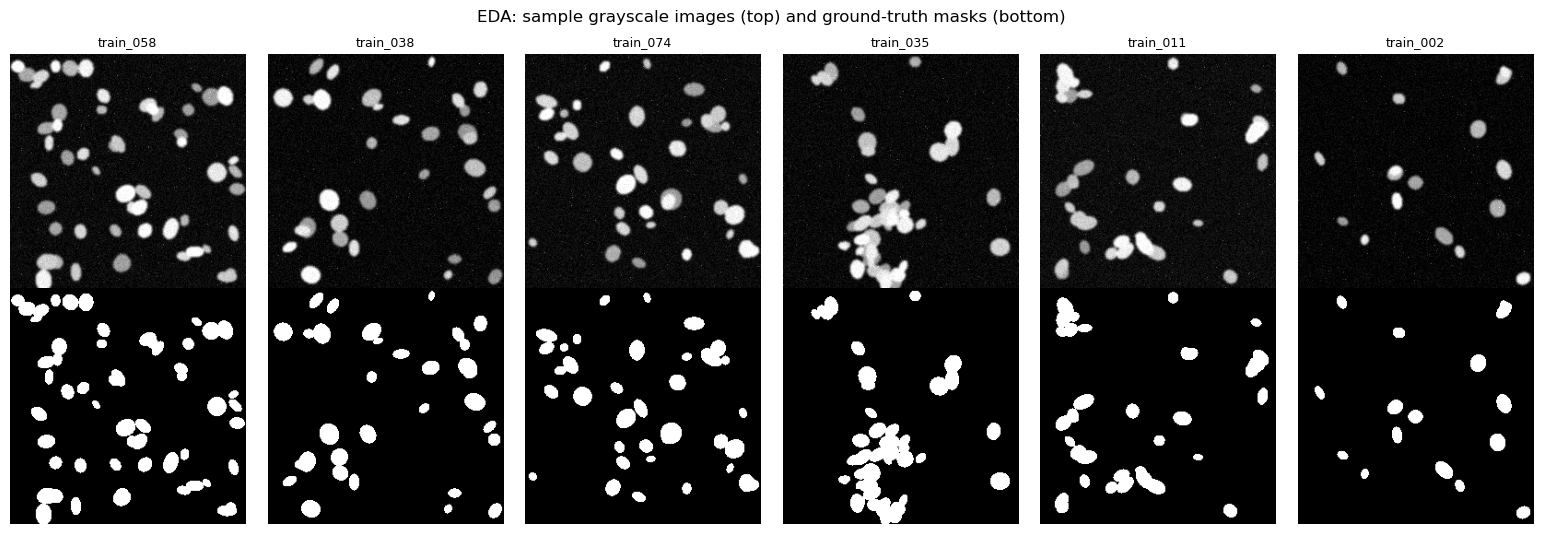

In [13]:
fig1 = plot_sample_grid(train_records, n=6, seed=1, save_path=os.path.join(OUT_FIG, "eda_sample_grid.png"))
plt.show()

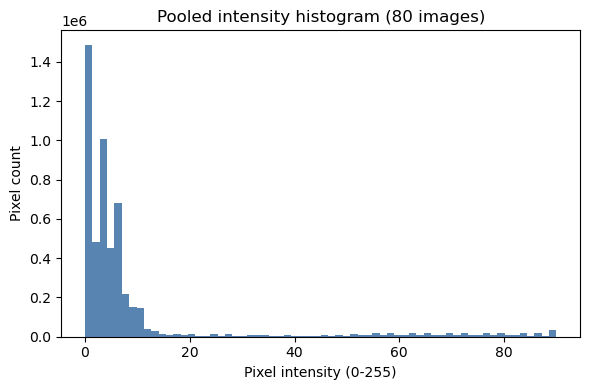

Pooled pixel intensity: mean=9.31  std=18.28  min=0  max=90


In [14]:
fig2, all_pixels = plot_intensity_histogram(train_records, save_path=os.path.join(OUT_FIG, "eda_intensity_histogram.png"))
plt.show()
print(f"Pooled pixel intensity: mean={all_pixels.mean():.2f}  std={all_pixels.std():.2f}  "
      f"min={all_pixels.min()}  max={all_pixels.max()}")

The histogram is strongly right-skewed with a large background peak near 0 

### Sending an image to the multimodal LLM (`llava:7b`)


Representative image: train_003


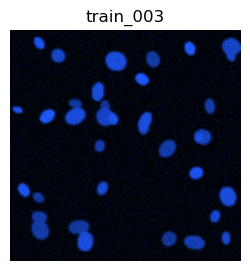

In [15]:
representative = train_records[3]
rep_rgb_path = representative.image_path  # already RGB PNG, 256x256
print("Representative image:", representative.image_id)

plt.figure(figsize=(3,3))
plt.imshow(load_rgb(rep_rgb_path)); plt.axis("off"); plt.title(representative.image_id)
plt.savefig(os.path.join(OUT_FIG, "task1_representative_image.png"), dpi=150, bbox_inches="tight")
plt.show()

#### Naive prompt vs engineered prompt

In [16]:
print("=== NAIVE PROMPT ===")
print(naive_vlm_prompt())
print()
print("=== ENGINEERED PROMPT ===")
print(engineered_vlm_prompt())

=== NAIVE PROMPT ===
What is this?

=== ENGINEERED PROMPT ===
You are assisting a researcher by describing a microscopy image. You are
NOT a diagnostic tool and must not provide a clinical diagnosis.

Look only at what is visible in the image. Respond with ONLY a single valid
JSON object (no markdown fences, no extra commentary) with exactly these
fields:

{
  "modality": string,            // e.g. "fluorescence microscopy", "unknown"
  "tissue_type": string,         // e.g. "cell nuclei", "unknown"
  "notable_features": [string],  // up to 4 short noun phrases you can see
  "image_quality": string        // one of: "good", "acceptable", "poor", "uncertain"
}

Rules:
- If you are not confident about a field, use the string "uncertain" (or an
  empty list for notable_features) rather than guessing.
- Do not invent details you cannot see in the image.
- Do not provide any diagnosis, disease name, or clinical recommendation.
- Output must be valid JSON and nothing else.


In [17]:
naive_response = chat_text(
    model=CONFIG.vlm_model, content=naive_vlm_prompt(), images=[rep_rgb_path], temperature=0.7,
)
print("=== NAIVE PROMPT OUTPUT ===")
print(naive_response)

=== NAIVE PROMPT OUTPUT ===
 The image you've provided appears to be a microscopic view of cells with blue dye. The blue dye is likely used for a particular cellular staining technique to visualize certain cellular components or structures. This kind of image is common in biological and medical sciences, particularly in fields such as histology, cytology, and molecular biology, where cells are stained to identify specific features or to count and analyze cells. 


In [ ]:
engineered_prose, engineered_record = chat_json(
    model=CONFIG.vlm_model, content=engineered_vlm_prompt(), images=[rep_rgb_path],
    temperature=CONFIG.llm_temperature, validator=validate_vlm_record,
)
print("=== ENGINEERED PROMPT OUTPUT (schema-validated) ===")
print(pd.DataFrame([engineered_record]))

### Run-to-run variability

In [ ]:
for i in range(3):
    prose_i, record_i = chat_json(
        model=CONFIG.vlm_model, content=engineered_vlm_prompt(), images=[rep_rgb_path],
        temperature=0.7, validator=validate_vlm_record,
    )
    print(f"--- Run {i+1} ---")
    print(record_i)
    print()

---
# Task 2 — Classical Features & Numbers-First LLM Interpretation

In [ ]:
gray = load_grayscale(representative.image_path)
binary_mask, label_img, feature_df = classical_pipeline(gray)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(gray, cmap="gray"); axes[0].set_title("grayscale input"); axes[0].axis("off")
axes[1].imshow(binary_mask, cmap="gray"); axes[1].set_title("Otsu + cleanup"); axes[1].axis("off")
axes[2].imshow(label_img, cmap="nipy_spectral"); axes[2].set_title(f"labelled ({label_img.max()} objects)"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "task2_classical_pipeline_example.png"), dpi=150, bbox_inches="tight")
plt.show()

feature_df.to_csv(os.path.join(OUT_CSV, "task2_feature_table_example.csv"), index=False)
feature_df.head(10).round(2)

In [ ]:
summary_text = summarize_features_as_text(feature_df, representative.image_id)
print(summary_text)

### Numbers-first prompt

In [ ]:
print(numbers_first_prompt(summary_text))

As with Task 1, this call requires a live Ollama server (`qwen2.5:3b` this time) and validates the JSON
half of the response against `validate_numbers_first_record`. The prose paragraph and the JSON record
are returned separately by `chat_json` (`extract_json_block` splits on the first `{` / last `}`), so we
can display both.

In [ ]:
numbers_first_prose, numbers_first_record = chat_json(
    model=CONFIG.text_llm_model, content=numbers_first_prompt(summary_text),
    temperature=CONFIG.llm_temperature, validator=validate_numbers_first_record,
)
print("=== NUMBERS-FIRST LLM OUTPUT (prose) ===")
print(numbers_first_prose)
print()
print("=== NUMBERS-FIRST LLM OUTPUT (schema-validated JSON) ===")
print(pd.DataFrame([numbers_first_record]))

---
# Task 3 — U-Net Segmentation


In [ ]:
unet_model, hist_df = train_or_load(
    tag="main", loss_name="bce_dice",
    train_records=train_records, val_records=val_records,
    out_dir=OUT_DIR, epochs=CONFIG.epochs, force=False,
)
n_params = sum(p.numel() for p in unet_model.parameters())
print(f"SmallUNet parameters: {n_params:,}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE+Dice loss"); axes[0].legend(); axes[0].set_title("Loss curves")

axes[1].plot(hist_df["epoch"], hist_df["val_dice"], label="val Dice", color="green")
axes[1].plot(hist_df["epoch"], hist_df["val_iou"], label="val IoU", color="orange")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("score"); axes[1].legend(); axes[1].set_title("Validation Dice / IoU")
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "unet_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

final_dice, final_iou = hist_df["val_dice"].iloc[-1], hist_df["val_iou"].iloc[-1]
print(f"Final validation Dice = {final_dice:.4f}   Final validation IoU = {final_iou:.4f}")

### Per-image validation scores, and input / ground-truth / prediction panels for the worst and best cases

In [ ]:
val_dataset = NucleiDataset(val_records)
scores = pd.DataFrame(per_image_scores(unet_model, val_dataset)).sort_values("dice")
scores.to_csv(os.path.join(OUT_CSV, "unet_per_image_val_scores.csv"), index=False)
print(scores.to_string(index=False))

In [ ]:
rec_by_id = {r.image_id: r for r in val_records}
chosen_ids = list(dict.fromkeys(
    scores.head(2)["image_id"].tolist()                       # 2 worst
    + [scores.iloc[len(scores)//2]["image_id"]]                # 1 median
    + scores.tail(1)["image_id"].tolist()                       # 1 best
))

fig, axes = plt.subplots(len(chosen_ids), 3, figsize=(9, 3 * len(chosen_ids)))
for row, img_id in enumerate(chosen_ids):
    r = rec_by_id[img_id]
    g = load_grayscale(r.image_path)
    gt = load_binary_mask(r.mask_path)
    x = torch.from_numpy(g.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        pred = (torch.sigmoid(unet_model(x)).squeeze().numpy() > 0.5).astype(np.uint8)
    d = float(scores.set_index("image_id").loc[img_id, "dice"])

    axes[row, 0].imshow(g, cmap="gray"); axes[row, 0].set_title(f"{img_id}: input"); axes[row, 0].axis("off")
    axes[row, 1].imshow(gt, cmap="gray"); axes[row, 1].set_title("ground truth"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred, cmap="gray"); axes[row, 2].set_title(f"prediction (Dice={d:.3f})"); axes[row, 2].axis("off")

fig.suptitle("U-Net: input / ground truth / prediction (validation split)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "unet_prediction_panels.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
response = chat(model=CONFIG.text_llm_model,
                 messages=[{"role": "user", "content": numbers_first_prompt(summary_text)}],
                 options={"temperature": CONFIG.llm_temperature})
print(response["message"]["content"])

In [ ]:
rows = []
for split_name, recs in [("val", val_records), ("test", test_records)]:
    for r in recs:
        g = load_grayscale(r.image_path)
        gt = load_binary_mask(r.mask_path)
        gt_t = torch.from_numpy(gt.astype(np.float32)).unsqueeze(0).unsqueeze(0)

        otsu_mask, _, _ = classical_pipeline(g)
        otsu_t = torch.from_numpy(otsu_mask.astype(np.float32)).unsqueeze(0).unsqueeze(0)
        otsu_dice, otsu_iou = dice_score(otsu_t, gt_t).item(), iou_score(otsu_t, gt_t).item()

        x = torch.from_numpy(g.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
        with torch.no_grad():
            probs = torch.sigmoid(unet_model(x))
        unet_dice, unet_iou = dice_score(probs, gt_t).item(), iou_score(probs, gt_t).item()

        rows.append(dict(image_id=r.image_id, split=split_name,
                          otsu_dice=otsu_dice, otsu_iou=otsu_iou,
                          unet_dice=unet_dice, unet_iou=unet_iou,
                          better_method="unet" if unet_dice > otsu_dice else "otsu",
                          dice_margin=abs(unet_dice - otsu_dice)))

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(os.path.join(OUT_CSV, "otsu_vs_unet_comparison.csv"), index=False)

print(comparison_df["better_method"].value_counts())
print()
print(f"Mean Otsu Dice = {comparison_df.otsu_dice.mean():.4f}   Mean U-Net Dice = {comparison_df.unet_dice.mean():.4f}")
print()
print("Row where Otsu came CLOSEST to (or beat) U-Net (smallest margin):")
print(comparison_df.loc[comparison_df.dice_margin.idxmin()])
print()
print("Row with the LARGEST margin (biggest advantage for the 'better_method' column):")
print(comparison_df.loc[comparison_df.dice_margin.idxmax()])

---
# Task 4 — Hybrid Pipeline on the Unseen Test Set


In [ ]:

def hybrid_record_prompt(image_id, feature_summary_text):
    return f'''You are a research assistant summarising automated nucleus-segmentation
results for image "{image_id}". You have NOT seen the image -- only these
measurements, computed from a trained segmentation model's output mask:

{feature_summary_text}

Write:
1. One short (1-2 sentence) plain-language narrative summarising these measurements. Do not claim
   to have seen the image.
2. Then, on a new line, output ONLY a single valid JSON object (no markdown fences, no comments).
   Here is an EXAMPLE of the exact format required (the values are just an example -- replace them
   with your own judgement, except "image_id" which must be exactly "{image_id}" as shown):

{{"image_id": "{image_id}", "n_objects": 12, "mean_area": 148.5, "density_class": "normal", "quality_flag": "good"}}

IMPORTANT about "density_class": this is a CATEGORY WORD, not a number. Choose exactly ONE of these
five words based on how crowded the nuclei look: sparse, normal, dense, clustered, uncertain. The
measurements above may include a raw numeric density figure (e.g. a foreground area fraction) --
do NOT copy that number into your answer or invent a new numeric field for it. Translate it into
one of the five words instead.

"quality_flag" must be one of: good, review_needed, uncertain.

Rules:
- Base every statement and field strictly on the measurements above. If unsure, use "uncertain".
- Output ONLY the five keys shown in the example above: image_id, n_objects, mean_area,
  density_class, quality_flag. Do not add any other key, and do not omit or rename any of the five.
- Do NOT put the narrative text inside the JSON object -- it goes in the separate paragraph in step 1.
- You MUST write the step-1 narrative sentence BEFORE the step-2 JSON object, in that order.'''

print("hybrid_record_prompt patched. Re-run the Task 4 cell now.")

In [ ]:
hybrid_df = run_hybrid_pipeline(unet_model, test_records, llm_model=CONFIG.text_llm_model)
hybrid_df.to_csv(os.path.join(OUT_CSV, "hybrid_pipeline_results.csv"), index=False)
hybrid_df

---
# Extension 1 — U-Net Loss Ablation (BCE vs Dice vs BCE+Dice)

In [ ]:
_, hist_bce  = train_or_load(tag="bce_only",  loss_name="bce",  train_records=train_records,
                              val_records=val_records, out_dir=OUT_DIR, epochs=CONFIG.epochs)
_, hist_dice = train_or_load(tag="dice_only", loss_name="dice", train_records=train_records,
                              val_records=val_records, out_dir=OUT_DIR, epochs=CONFIG.epochs)


ablation_summary = pd.DataFrame({
    "loss_function": ["BCE only", "Dice only", "BCE + Dice (Task 3 model)"],
    "final_val_dice": [hist_bce["val_dice"].iloc[-1], hist_dice["val_dice"].iloc[-1], hist_df["val_dice"].iloc[-1]],
    "final_val_iou":  [hist_bce["val_iou"].iloc[-1],  hist_dice["val_iou"].iloc[-1],  hist_df["val_iou"].iloc[-1]],
    "best_val_dice":  [hist_bce["val_dice"].max(),    hist_dice["val_dice"].max(),    hist_df["val_dice"].max()],
})
ablation_summary.to_csv(os.path.join(OUT_CSV, "loss_ablation_summary.csv"), index=False)
ablation_summary.round(4)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(hist_bce["epoch"], hist_bce["val_dice"], marker="o", ms=3, label="BCE only")
ax.plot(hist_dice["epoch"], hist_dice["val_dice"], marker="s", ms=3, label="Dice only")
ax.plot(hist_df["epoch"], hist_df["val_dice"], marker="^", ms=3, label="BCE + Dice")
ax.set_xlabel("epoch"); ax.set_ylabel("validation Dice"); ax.set_title("Loss ablation: validation Dice per epoch")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "loss_ablation_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

---
# Extension 2 — Robustness: Tracing a Corruption Through the Pipeline


In [ ]:
image_id = "test_000"
gt_mask = load_binary_mask(os.path.join(DATA_ROOT, "test", "masks", f"{image_id}.png"))
orig_gray = load_grayscale(os.path.join(DATA_ROOT, "test", "images", f"{image_id}.png"))

variants = {
    "original": orig_gray,
    "blur (dataset)": load_grayscale(os.path.join(DATA_ROOT, "test_corrupted", "images", f"{image_id}_blur.png")),
    "low_contrast (dataset)": load_grayscale(os.path.join(DATA_ROOT, "test_corrupted", "images", f"{image_id}_lowcontrast.png")),
    "noise (synthetic)": corrupt_image(orig_gray, "noise"),
}

rows = []
fig, axes = plt.subplots(2, len(variants), figsize=(3.2 * len(variants), 6.4))
gt_t = torch.from_numpy(gt_mask.astype(np.float32)).unsqueeze(0).unsqueeze(0)

for col, (name, g) in enumerate(variants.items()):
    otsu_mask, _, otsu_df = classical_pipeline(g)
    otsu_t = torch.from_numpy(otsu_mask.astype(np.float32)).unsqueeze(0).unsqueeze(0)
    otsu_dice = dice_score(otsu_t, gt_t).item()

    x = torch.from_numpy(g.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        probs = torch.sigmoid(unet_model(x))
    unet_pred = (probs.squeeze().numpy() > 0.5).astype(np.uint8)
    unet_dice = dice_score(probs, gt_t).item()

    rows.append(dict(variant=name, otsu_n_objects=len(otsu_df), otsu_dice=round(otsu_dice, 4),
                      unet_dice=round(unet_dice, 4), mean_intensity=round(float(g.mean()), 2),
                      std_intensity=round(float(g.std()), 2)))

    axes[0, col].imshow(g, cmap="gray"); axes[0, col].set_title(name, fontsize=9); axes[0, col].axis("off")
    axes[1, col].imshow(unet_pred, cmap="gray"); axes[1, col].set_title(f"U-Net pred (Dice={unet_dice:.3f})", fontsize=8); axes[1, col].axis("off")

fig.suptitle(f"Robustness extension: corruption trace for {image_id}")
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "robustness_corruption_trace.png"), dpi=150, bbox_inches="tight")
plt.show()

trace_df = pd.DataFrame(rows)
trace_df.to_csv(os.path.join(OUT_CSV, "robustness_corruption_trace.csv"), index=False)
trace_df